========== Complete Stock Price Analyser ==========

--------------------------------
Company Name: Reliance Industries Limited
Current Price: 1295.5 INR
Change: +2.50 (+0.19%)
--------------------------------



/tmp/ipykernel_1099/3551658997.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


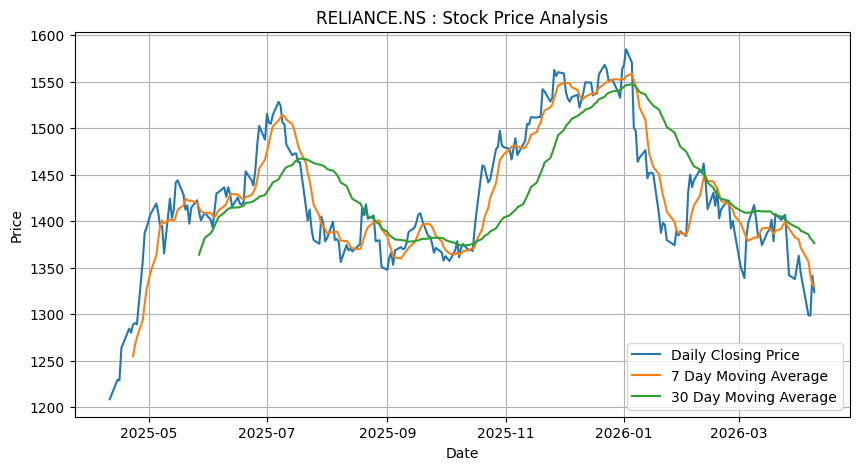

In [ ]:
# Web Scrapping
# Automation

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

print("========== Complete Stock Price Analyser ==========")

while True:
    symbol = input(
        "Enter the stock symbol (Add '.NS' in case of Indian stocks) (or Q to Quit): "
    ).upper()

    if symbol == "Q":
        print("Thanks for using. See you again!!")
        break

    try:
        # Fetch stock details
        stock = yf.Ticker(symbol)
        info = stock.info

        name = info.get("longName", "N/A")
        price = info.get("currentPrice")
        prev_price = info.get("previousClose")
        currency = info.get("currency")

        print("\n--------------------------------")
        print(f"Company Name: {name}")
        print(f"Current Price: {price} {currency}")

        # Calculate price change
        if price and prev_price:
            change = price - prev_price
            percent = (change / prev_price) * 100
            print(f"Change: {change:+.2f} ({percent:+.2f}%)")

        print("--------------------------------\n")

        # Download historical data
        df = yf.download(
            symbol,
            start="2025-04-10",
            end="2026-04-10",
            interval="1d"
        )

        # Calculate Moving Averages
        df["7_day_MA"] = df["Close"].rolling(window=7).mean()
        df["30_day_MA"] = df["Close"].rolling(window=30).mean()

        # Plot the graph
        plt.figure(figsize=(10, 5))
        plt.plot(df["Close"], label="Daily Closing Price")
        plt.plot(df["7_day_MA"], label="7 Day Moving Average")
        plt.plot(df["30_day_MA"], label="30 Day Moving Average")

        plt.title(f"{symbol} : Stock Price Analysis")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True)
        plt.show()

    except Exception as e:
        print("Invalid Symbol or Network Error")